In [ ]:
# ============================================================================
# 1. IMPORTS AND REPRODUCIBILITY
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
SEED = 12345
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=4, suppress=True)

In [ ]:
# ============================================================================
# 2. OBSERVED DATA - WEEKLY RADIOTHERAPY ATTENDANCE
# ============================================================================
# Source: donnees.xlsx
# Temporal resolution: weekly
# Observation period: 84 weeks
#
# Y_obs[i] = number of radiotherapy attendances observed during week i
# ============================================================================

Y_obs = np.array([
    26, 20, 58, 39, 29, 49, 48, 43, 44, 35,
    42, 60, 43, 38, 53, 51, 35, 42, 37, 48,
    28, 30, 27, 42, 45, 37, 39, 19, 29, 19,
    23, 28, 36, 17, 25, 35, 28, 27, 34, 34,
    39, 22, 64, 41, 53, 52, 52, 57, 62, 47,
    61, 62, 60, 57, 43, 51, 38, 39, 56, 47,
    49, 58, 56, 60, 46, 39, 54, 51, 40, 49,
    56, 55, 49, 41, 38, 72, 59, 61, 48, 46,
    63, 38, 59, 19
], dtype=int)

N = len(Y_obs)

print(f"Number of weekly observations: {N}")
print(f"Minimum observed count: {Y_obs.min()}")
print(f"Maximum observed count: {Y_obs.max()}")

Number of weekly observations: 84
Minimum observed count: 17
Maximum observed count: 72


In [ ]:
# ============================================================================
# 3. CHRONOLOGICAL TRAIN-TEST SPLIT
# ============================================================================
# 80% of the earliest observations are used for Bayesian calibration.
# The final 20% are kept completely out of the estimation procedure and
# are used only for out-of-sample predictive evaluation.
# ============================================================================

TRAIN_FRACTION = 0.80

n_train = int(TRAIN_FRACTION * N)
n_test = N - n_train

Y_train = Y_obs[:n_train]
Y_test = Y_obs[n_train:]

# Time is measured in weeks.
# The first observation defines t = 0.
t_obs = np.arange(N, dtype=float)

t_train = t_obs[:n_train]
t_test = t_obs[n_train:]

print(f"Total number of observations : {N}")
print(f"Training observations        : {n_train}")
print(f"Test observations            : {n_test}")

print(f"\nTraining period: t = {t_train[0]:.0f} to {t_train[-1]:.0f} weeks")
print(f"Test period    : t = {t_test[0]:.0f} to {t_test[-1]:.0f} weeks")

Total number of observations : 84
Training observations        : 67
Test observations            : 17

Training period: t = 0 to 66 weeks
Test period    : t = 67 to 83 weeks


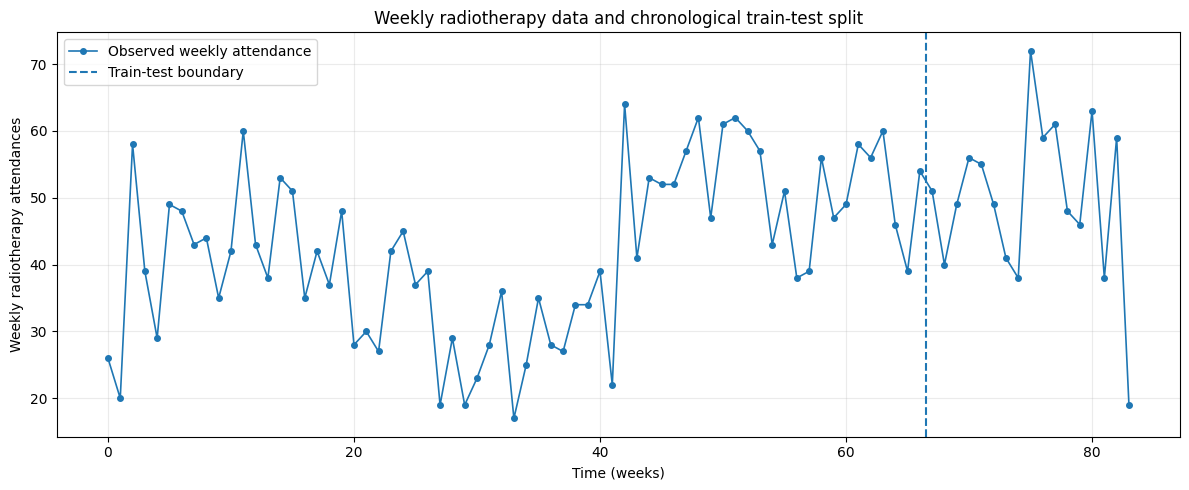

In [ ]:
# ============================================================================
# 4. VISUAL CHECK OF THE TRAIN-TEST SPLIT
# ============================================================================

plt.figure(figsize=(12, 5))

plt.plot(
    t_obs,
    Y_obs,
    marker="o",
    markersize=4,
    linewidth=1.2,
    label="Observed weekly attendance"
)

plt.axvline(
    x=t_test[0] - 0.5,
    linestyle="--",
    linewidth=1.5,
    label="Train-test boundary"
)

plt.xlabel("Time (weeks)")
plt.ylabel("Weekly radiotherapy attendances")
plt.title("Weekly radiotherapy data and chronological train-test split")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# 5. BASIC DESCRIPTIVE STATISTICS
# ============================================================================

def descriptive_statistics(y, name):
    mean_y = np.mean(y)
    variance_y = np.var(y, ddof=1)
    std_y = np.std(y, ddof=1)

    print(f"{name}")
    print("-" * len(name))
    print(f"Number of observations : {len(y)}")
    print(f"Mean                   : {mean_y:.3f}")
    print(f"Variance               : {variance_y:.3f}")
    print(f"Standard deviation     : {std_y:.3f}")
    print(f"Minimum                : {np.min(y)}")
    print(f"Maximum                : {np.max(y)}")
    print(f"Variance / Mean        : {variance_y / mean_y:.3f}")
    print()


descriptive_statistics(Y_train, "Training data")
descriptive_statistics(Y_test, "Test data")
descriptive_statistics(Y_obs, "Full dataset")

Training data
-------------
Number of observations : 67
Mean                   : 41.896
Variance               : 157.610
Standard deviation     : 12.554
Minimum                : 17
Maximum                : 64
Variance / Mean        : 3.762

Test data
---------
Number of observations : 17
Mean                   : 49.647
Variance               : 152.993
Standard deviation     : 12.369
Minimum                : 19
Maximum                : 72
Variance / Mean        : 3.082

Full dataset
------------
Number of observations : 84
Mean                   : 43.464
Variance               : 164.637
Standard deviation     : 12.831
Minimum                : 17
Maximum                : 72
Variance / Mean        : 3.788



In [ ]:
# ============================================================================
# 6. FIXED MODEL PARAMETERS - WEEKLY TIME SCALE
# ============================================================================

from scipy.integrate import solve_ivp

# ---------------------------------------------------------------------------
# Observation parameters
# ---------------------------------------------------------------------------

PI_RT = 0.12

# Maison et al.: 27 radiotherapy sessions over 57.34 days
# Convert treatment duration from days to weeks
TREATMENT_DURATION_WEEKS = 57.34 / 7.0

KAPPA = 27.0 / TREATMENT_DURATION_WEEKS
# sessions / patient / week


# ---------------------------------------------------------------------------
# Natural exit rates
# ---------------------------------------------------------------------------

# Curative treatment:
# mean treatment duration = 57.34 days
MU_T = 1.0 / TREATMENT_DURATION_WEEKS

# Pre-treatment assessment:
# median diagnosis-to-radiotherapy delay = 89 days
MU_B = 1.0 / (89.0 / 7.0)

# Post-treatment follow-up:
# 36 months ≈ 156 weeks
FOLLOWUP_DURATION_WEEKS = 36.0 * 52.0 / 12.0
MU_R = 1.0 / FOLLOWUP_DURATION_WEEKS

# Palliative care:
# median survival = 13 months
PALLIATIVE_DURATION_WEEKS = 13.0 * 52.0 / 12.0
MU_P = 1.0 / PALLIATIVE_DURATION_WEEKS


# ---------------------------------------------------------------------------
# Financially regulated transition rates
# ---------------------------------------------------------------------------
# Original values were expressed in (FCFA.day)^(-1).
# Conversion to weekly time scale: multiply by 7.
# ---------------------------------------------------------------------------

BETA1 = 1.5e-6 * 7.0
BETA2 = 5.0e-7 * 7.0
GAMMA = 8.0e-7 * 7.0


# ---------------------------------------------------------------------------
# Economic parameters
# ---------------------------------------------------------------------------

P_RT = 511_264.0     # FCFA
P_S  = 500_000.0     # FCFA

P_T = PI_RT * P_RT + (1.0 - PI_RT) * P_S

P_R = 50_000.0       # FCFA
P_P = 100_000.0      # FCFA


# ---------------------------------------------------------------------------
# Display fixed parameters
# ---------------------------------------------------------------------------

fixed_parameters = pd.DataFrame({
    "Parameter": [
        "pi_RT", "kappa",
        "mu_B", "mu_T", "mu_R", "mu_P",
        "beta1", "beta2", "gamma",
        "p_T", "p_R", "p_P"
    ],
    "Value": [
        PI_RT, KAPPA,
        MU_B, MU_T, MU_R, MU_P,
        BETA1, BETA2, GAMMA,
        P_T, P_R, P_P
    ],
    "Unit": [
        "dimensionless",
        "sessions / patient / week",
        "week^-1",
        "week^-1",
        "week^-1",
        "week^-1",
        "(FCFA.week)^-1",
        "(FCFA.week)^-1",
        "(FCFA.week)^-1",
        "FCFA",
        "FCFA",
        "FCFA"
    ]
})

display(fixed_parameters)

,Parameter,Value,Unit
0,pi_RT,0.120000,dimensionless
1,kappa,3.296128,sessions / patient / week
2,mu_B,0.078652,week^-1
3,mu_T,0.122079,week^-1
4,mu_R,0.006410,week^-1
5,mu_P,0.017751,week^-1
6,beta1,0.000011,(FCFA.week)^-1
7,beta2,0.000003,(FCFA.week)^-1
8,gamma,0.000006,(FCFA.week)^-1
9,p_T,501351.680000,FCFA


In [ ]:
# ============================================================================
# 7. INITIAL CONDITIONS
# ============================================================================
# The first observed weekly attendance is used ONLY to initialize the model.
# It will NOT be used later in the likelihood.
# ============================================================================

Y_INITIAL = Y_train[0]

# Initial number of women under curative treatment
T_init = Y_INITIAL / (KAPPA * PI_RT)

# Residence-time approximation
B_init = T_init * MU_T / MU_B
R_init = T_init * MU_T / MU_R
P_init = T_init * MU_T / MU_P

# Initial pooled financial resource
# Fixed independently of all parameters to be estimated.
M_init = 10000000

X0 = np.array([
    B_init,
    T_init,
    R_init,
    P_init,
    M_init
], dtype=float)

state_names = ["B", "T", "R", "P", "M"]

initial_conditions = pd.DataFrame({
    "State": state_names,
    "Initial value": X0
})

display(initial_conditions)

print(f"First weekly observation used for initialization: {Y_INITIAL}")
print(f"T(0) = {T_init:.4f}")
print(f"B(0) = {B_init:.4f}")
print(f"R(0) = {R_init:.4f}")
print(f"P(0) = {P_init:.4f}")
print(f"M(0) = {M_init:.4f}")

,State,Initial value
0,B,1.020282e+02
1,T,6.573369e+01
2,R,1.251852e+03
3,P,4.520576e+02
4,M,1.000000e+07


First weekly observation used for initialization: 26
T(0) = 65.7337
B(0) = 102.0282
R(0) = 1251.8519
P(0) = 452.0576
M(0) = 10000000.0000


In [ ]:
# ============================================================================
# 8. DATA ACTUALLY USED IN THE BAYESIAN LIKELIHOOD
# ============================================================================
# Week 1 is used to construct the initial conditions.
# Therefore, Bayesian calibration starts from week 2.
# ============================================================================

Y_calib = Y_train[1:]
t_calib = t_train[1:]

print(f"Training observations available : {len(Y_train)}")
print(f"Used for initialization         : 1")
print(f"Used in Bayesian likelihood     : {len(Y_calib)}")
print(f"Independent test observations   : {len(Y_test)}")

print(f"\nLikelihood period: week {int(t_calib[0])} to week {int(t_calib[-1])}")
print(f"Test period      : week {int(t_test[0])} to week {int(t_test[-1])}")

assert len(Y_calib) == 66
assert len(Y_test) == 17

Training observations available : 67
Used for initialization         : 1
Used in Bayesian likelihood     : 66
Independent test observations   : 17

Likelihood period: week 1 to week 66
Test period      : week 67 to week 83


In [ ]:
# ============================================================================
# 9. ODE SYSTEM
# ============================================================================
#
# State vector:
# X = [B, T, R, P, M]
#
# Estimated mechanistic parameters:
# theta = [Lambda, alpha, q, mu_M]
#
# All time-dependent parameters use WEEK as the time unit.
# ============================================================================

def care_pathway_ode(t, X, theta):
    """
    Cervical cancer care pathway model.

    Parameters
    ----------
    t : float
        Time in weeks.

    X : array-like, shape (5,)
        Current state:
        [B, T, R, P, M].

    theta : array-like, shape (4,)
        Unknown mechanistic parameters:
        [Lambda, alpha, q, mu_M].

    Returns
    -------
    dXdt : ndarray, shape (5,)
        Time derivatives of the five state variables.
    """

    B, T, R, P, M = X

    Lambda, alpha, q, mu_M = theta

    # Total number of women in active care
    N = T + R + P

    # --------------------------------------------------
    # Patient dynamics
    # --------------------------------------------------

    dBdt = (
        Lambda
        - alpha * M * B
        - MU_B * B
    )

    dTdt = (
        alpha * M * B
        + BETA2 * M * R
        - BETA1 * M * T
        - MU_T * T
    )

    dRdt = (
        BETA1 * M * T
        - (BETA2 + GAMMA) * M * R
        - MU_R * R
    )

    dPdt = (
        GAMMA * M * R
        - MU_P * P
    )

    # --------------------------------------------------
    # Financial dynamics
    # --------------------------------------------------

    treatment_cost = P_T * (
        alpha * M * B
        + BETA2 * M * R
    )

    followup_cost = P_R * BETA1 * M * T

    palliative_cost = P_P * GAMMA * M * R

    dMdt = (
        q * N
        - mu_M * M
        - treatment_cost
        - followup_cost
        - palliative_cost
    )

    return np.array([
        dBdt,
        dTdt,
        dRdt,
        dPdt,
        dMdt
    ])

In [ ]:
# ============================================================================
# 10. NUMERICAL ODE SOLVER
# ============================================================================

def simulate_model(
    theta,
    t_eval,
    X_init=X0,
    rtol=1e-8,
    atol=1e-10
):
    """
    Solve the ODE system for a given parameter vector.

    Parameters
    ----------
    theta : array-like
        [Lambda, alpha, q, mu_M]

    t_eval : array-like
        Times at which the solution is required.

    X_init : array-like
        Initial state [B0, T0, R0, P0, M0].

    rtol, atol : float
        Numerical tolerances for the ODE solver.

    Returns
    -------
    solution : scipy OdeResult
        Numerical solution returned by solve_ivp.
    """

    theta = np.asarray(theta, dtype=float)
    t_eval = np.asarray(t_eval, dtype=float)

    if theta.shape != (4,):
        raise ValueError(
            "theta must contain exactly four parameters: "
            "[Lambda, alpha, q, mu_M]."
        )

    if np.any(theta <= 0):
        raise ValueError(
            "All estimated mechanistic parameters must be strictly positive."
        )

    if np.any(np.diff(t_eval) < 0):
        raise ValueError("t_eval must be sorted in increasing order.")

    solution = solve_ivp(
        fun=lambda t, X: care_pathway_ode(t, X, theta),
        t_span=(float(t_eval[0]), float(t_eval[-1])),
        y0=X_init,
        t_eval=t_eval,
        method="LSODA",
        rtol=rtol,
        atol=atol
    )

    if not solution.success:
        raise RuntimeError(
            f"ODE solver failed: {solution.message}"
        )

    if not np.all(np.isfinite(solution.y)):
        raise RuntimeError(
            "ODE solution contains NaN or infinite values."
        )

    return solution

In [ ]:
# ============================================================================
# 11. OBSERVATION MODEL
# ============================================================================
# Converts the latent treatment compartment T(t) into the expected
# weekly number of radiotherapy attendances.
# ============================================================================

def expected_rt_attendance(T):
    """
    Expected weekly radiotherapy attendance.

    Parameters
    ----------
    T : float or array-like
        Number of women in curative treatment.

    Returns
    -------
    m : float or ndarray
        Expected number of radiotherapy attendances per week.
    """

    return KAPPA * PI_RT * np.asarray(T)


def extract_expected_attendance(solution):
    """
    Extract expected weekly RT attendance from an ODE solution.
    """

    T = solution.y[1, :]

    return expected_rt_attendance(T)

In [ ]:
# ============================================================================
# 12. INITIAL OBSERVATION CONSISTENCY CHECK
# ============================================================================

Y0_model = expected_rt_attendance(T_init)

print(f"Observed first-week attendance : {Y_INITIAL:.6f}")
print(f"Model attendance at t = 0      : {Y0_model:.6f}")

assert np.isclose(
    Y0_model,
    Y_INITIAL,
    rtol=1e-12,
    atol=1e-12
)

print("\nInitial observation mapping is consistent.")

Observed first-week attendance : 26.000000
Model attendance at t = 0      : 26.000000

Initial observation mapping is consistent.


In [ ]:
# ============================================================================
# 13. LOGNORMAL PRIOR CONSTRUCTION
# ============================================================================
# For each positive parameter theta:
#
#     log(theta) ~ Normal(m, s^2)
#
# We specify an approximate 95% prior interval [L, U].
# Then:
#
#     m = (log(L) + log(U)) / 2
#     s = (log(U) - log(L)) / (2 * 1.96)
#
# IMPORTANT:
# [L, U] is NOT a hard constraint. A lognormal distribution still has
# positive probability outside this interval.
# ============================================================================

def lognormal_from_interval(L, U, probability=0.95):
    """
    Compute the parameters (m, s) of a lognormal distribution
    from an approximate central 95% interval [L, U].

    log(theta) ~ Normal(m, s^2)
    """

    if L <= 0 or U <= 0:
        raise ValueError("L and U must be strictly positive.")

    if L >= U:
        raise ValueError("L must be smaller than U.")

    # For a central 95% interval
    z = 1.96

    m = 0.5 * (np.log(L) + np.log(U))
    s = (np.log(U) - np.log(L)) / (2.0 * z)

    return m, s

In [ ]:
# ============================================================================
# 14. WORKING PRIOR SPECIFICATION
# ============================================================================
#
# Approximate central 95% intervals.
#
# These priors are deliberately broad.
# They are NOT derived from the current fitting dataset.
# Their adequacy will be assessed using prior predictive simulations.
# ============================================================================

PRIOR_INTERVALS = {
    "Lambda": (5.0, 500.0),        # patients / week

    "alpha":  (1.0e-8, 1.0e-4),   # (FCFA.week)^-1

    "q":      (500.0, 200_000.0),  # FCFA / patient / week

    "mu_M":   (0.005, 2.0),        # week^-1

    "phi":    (0.5, 100.0)         # dimensionless NB dispersion
}


prior_parameters = {}

for name, (L, U) in PRIOR_INTERVALS.items():

    m, s = lognormal_from_interval(L, U)

    prior_parameters[name] = {
        "L": L,
        "U": U,
        "m": m,
        "s": s,
        "median": np.exp(m)
    }


prior_table = pd.DataFrame(
    [
        {
            "Parameter": name,
            "95% lower": values["L"],
            "95% upper": values["U"],
            "log-mean m": values["m"],
            "log-SD s": values["s"],
            "prior median": values["median"]
        }
        for name, values in prior_parameters.items()
    ]
)

display(prior_table)

,Parameter,95% lower,95% upper,log-mean m,log-SD s,prior median
0,Lambda,5.000000e+00,500.0000,3.912023,1.174788,50.000000
1,alpha,1.000000e-08,0.0001,-13.815511,2.349577,0.000001
2,q,5.000000e+02,200000.0000,9.210340,1.528435,10000.000000
3,mu_M,5.000000e-03,2.0000,-2.302585,1.528435,0.100000
4,phi,5.000000e-01,100.0000,1.956012,1.351612,7.071068


In [ ]:
# ============================================================================
# 15. SAMPLING FROM THE PRIOR DISTRIBUTIONS
# ============================================================================

def sample_lognormal_prior(name, size=1, rng=rng):
    """
    Draw samples from the lognormal prior of a parameter.
    """

    pars = prior_parameters[name]

    return rng.lognormal(
        mean=pars["m"],
        sigma=pars["s"],
        size=size
    )


def sample_prior_parameters(size=1, rng=rng):
    """
    Draw complete parameter vectors from the joint prior.

    Returns
    -------
    dict containing:
        Lambda
        alpha
        q
        mu_M
        phi
    """

    samples = {
        name: sample_lognormal_prior(
            name=name,
            size=size,
            rng=rng
        )
        for name in PRIOR_INTERVALS
    }

    return samples

In [ ]:
prior_test = sample_prior_parameters(size=5)

pd.DataFrame(prior_test)

,Lambda,alpha,q,mu_M,phi
0,9.387040,1.753861e-07,361567.149625,0.091141,42.234814
1,220.662951,4.020621e-08,43941.952424,0.333909,4.715880
2,17.978557,4.593413e-06,3132.750192,0.014650,23.960526
3,36.875572,2.335752e-06,39707.352100,0.241129,0.789987
4,45.764586,1.016910e-08,4898.248035,0.848456,5.709897


In [ ]:
# ============================================================================
# 16. NUMERICAL CHECK OF PRIOR DISTRIBUTIONS
# ============================================================================

N_PRIOR_CHECK = 100_000

prior_check = sample_prior_parameters(
    size=N_PRIOR_CHECK
)

rows = []

for name in PRIOR_INTERVALS:

    samples = prior_check[name]

    rows.append({
        "Parameter": name,
        "2.5%": np.quantile(samples, 0.025),
        "Median": np.median(samples),
        "97.5%": np.quantile(samples, 0.975),
        "Mean": np.mean(samples)
    })

prior_check_table = pd.DataFrame(rows)

display(prior_check_table)

,Parameter,2.5%,Median,97.5%,Mean
0,Lambda,4.956949e+00,5.054046e+01,503.427282,100.190395
1,alpha,1.013902e-08,9.929201e-07,0.000098,0.000016
2,q,4.986339e+02,1.008985e+04,201670.643874,32363.623550
3,mu_M,5.063245e-03,9.931764e-02,2.025974,0.321540
4,phi,5.060118e-01,7.129799e+00,100.184329,17.622366


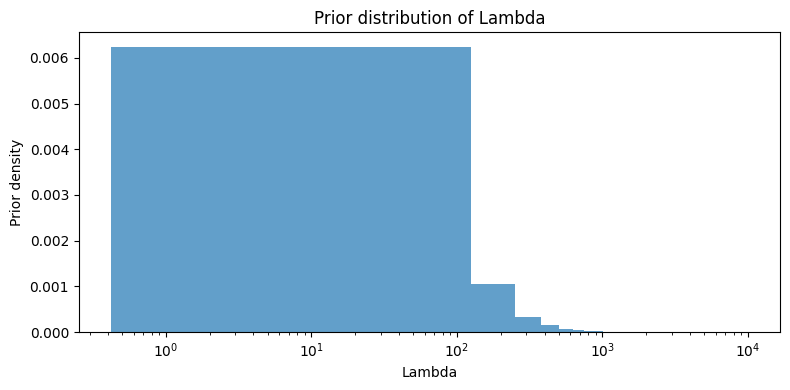

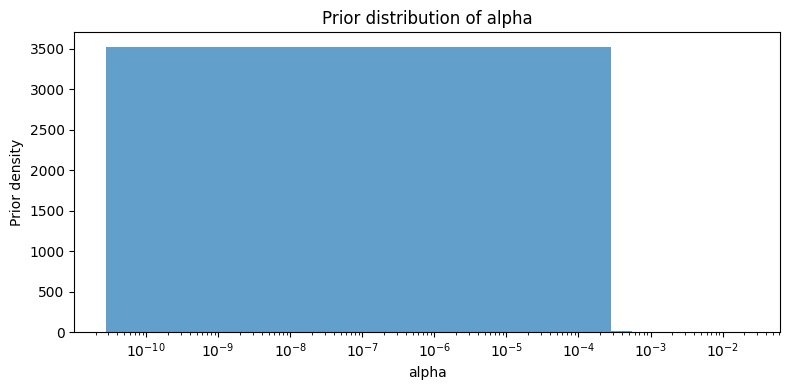

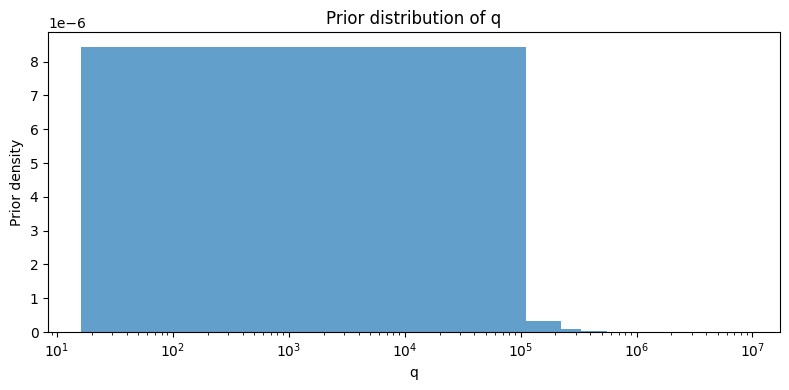

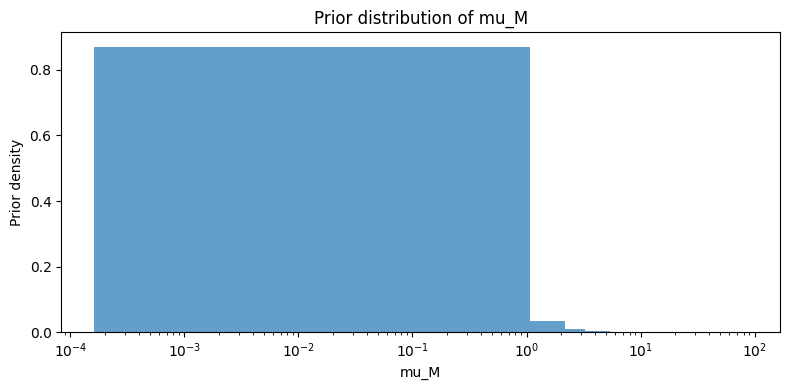

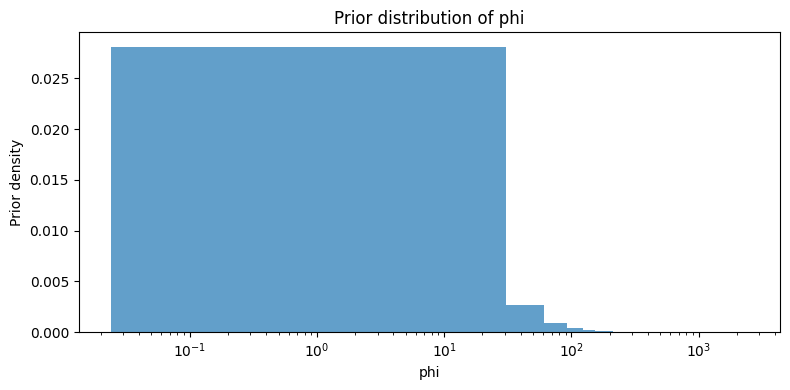

In [ ]:
# ============================================================================
# 17. PRIOR DISTRIBUTION PLOTS
# ============================================================================

for name in PRIOR_INTERVALS:

    samples = prior_check[name]

    plt.figure(figsize=(8, 4))

    plt.hist(
        samples,
        bins=80,
        density=True,
        alpha=0.7
    )

    plt.xscale("log")

    plt.xlabel(name)
    plt.ylabel("Prior density")
    plt.title(f"Prior distribution of {name}")

    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================================
# 18. SAFE PRIOR SIMULATION
# ============================================================================

def safe_simulate(theta, t_eval, X_init=X0):
    """
    Solve the ODE model safely.

    Returns
    -------
    solution : OdeResult or None

    valid : bool
        True if the numerical solution is finite and physically acceptable.
    """

    try:

        solution = simulate_model(
            theta=theta,
            t_eval=t_eval,
            X_init=X_init
        )

    except Exception:
        return None, False

    X = solution.y

    # ------------------------------------------------------------
    # Numerical validity
    # ------------------------------------------------------------

    if not np.all(np.isfinite(X)):
        return None, False

    # ------------------------------------------------------------
    # Positivity check
    # Allow very small numerical negative values
    # ------------------------------------------------------------

    numerical_tolerance = -1.0e-6

    if np.any(X < numerical_tolerance):
        return None, False

    # ------------------------------------------------------------
    # Prevent completely unrealistic numerical explosions
    # This is NOT a prior bound; it is only a computational safeguard.
    # ------------------------------------------------------------

    if np.max(X[:4, :]) > 1.0e7:
        return None, False

    if np.max(X[4, :]) > 1.0e12:
        return None, False

    return solution, True

In [ ]:
# ============================================================================
# 19. PRIOR PREDICTIVE SIMULATION
# ============================================================================
#
# IMPORTANT:
# The test dataset is NOT used here.
#
# We simulate only over the training interval.
# ============================================================================

N_PRIOR_PRED = 500

prior_draws = sample_prior_parameters(
    size=N_PRIOR_PRED
)

prior_mean_predictions = []
prior_predictive_counts = []

valid_parameter_draws = []

n_failed = 0


for s in range(N_PRIOR_PRED):

    # ------------------------------------------------------------
    # Mechanistic parameters
    # ------------------------------------------------------------

    theta_s = np.array([
        prior_draws["Lambda"][s],
        prior_draws["alpha"][s],
        prior_draws["q"][s],
        prior_draws["mu_M"][s]
    ])

    phi_s = prior_draws["phi"][s]

    # ------------------------------------------------------------
    # Solve ODE over complete training period
    # ------------------------------------------------------------

    solution, valid = safe_simulate(
        theta=theta_s,
        t_eval=t_train
    )

    if not valid:
        n_failed += 1
        continue

    # ------------------------------------------------------------
    # Expected radiotherapy attendance
    # ------------------------------------------------------------

    mean_attendance = extract_expected_attendance(
        solution
    )

    # We exclude week 1 because it defines the initial condition.
    mean_calib = mean_attendance[1:]

    if np.any(mean_calib <= 0):
        n_failed += 1
        continue

    # ------------------------------------------------------------
    # Negative-binomial observation model
    #
    # Var(Y) = mu + mu^2 / phi
    #
    # numpy parameterization:
    #
    # p = phi / (phi + mu)
    # n = phi
    # ------------------------------------------------------------

    prob_s = phi_s / (
        phi_s + mean_calib
    )

    y_rep = rng.negative_binomial(
        n=phi_s,
        p=prob_s
    )

    # ------------------------------------------------------------
    # Store results
    # ------------------------------------------------------------

    prior_mean_predictions.append(
        mean_calib
    )

    prior_predictive_counts.append(
        y_rep
    )

    valid_parameter_draws.append(
        np.append(theta_s, phi_s)
    )


prior_mean_predictions = np.asarray(
    prior_mean_predictions
)

prior_predictive_counts = np.asarray(
    prior_predictive_counts
)

valid_parameter_draws = np.asarray(
    valid_parameter_draws
)


print(
    f"Requested prior draws : {N_PRIOR_PRED}"
)

print(
    f"Valid simulations     : {len(prior_mean_predictions)}"
)

print(
    f"Failed simulations    : {n_failed}"
)

print(
    f"Failure rate          : "
    f"{100*n_failed/N_PRIOR_PRED:.2f}%"
)

Requested prior draws : 500
Valid simulations     : 500
Failed simulations    : 0
Failure rate          : 0.00%


In [ ]:
# ============================================================================
# 20. PRIOR PREDICTIVE INTERVALS
# ============================================================================

prior_mean_median = np.median(
    prior_mean_predictions,
    axis=0
)

prior_mean_lower = np.quantile(
    prior_mean_predictions,
    0.025,
    axis=0
)

prior_mean_upper = np.quantile(
    prior_mean_predictions,
    0.975,
    axis=0
)


prior_pred_median = np.median(
    prior_predictive_counts,
    axis=0
)

prior_pred_lower = np.quantile(
    prior_predictive_counts,
    0.025,
    axis=0
)

prior_pred_upper = np.quantile(
    prior_predictive_counts,
    0.975,
    axis=0
)

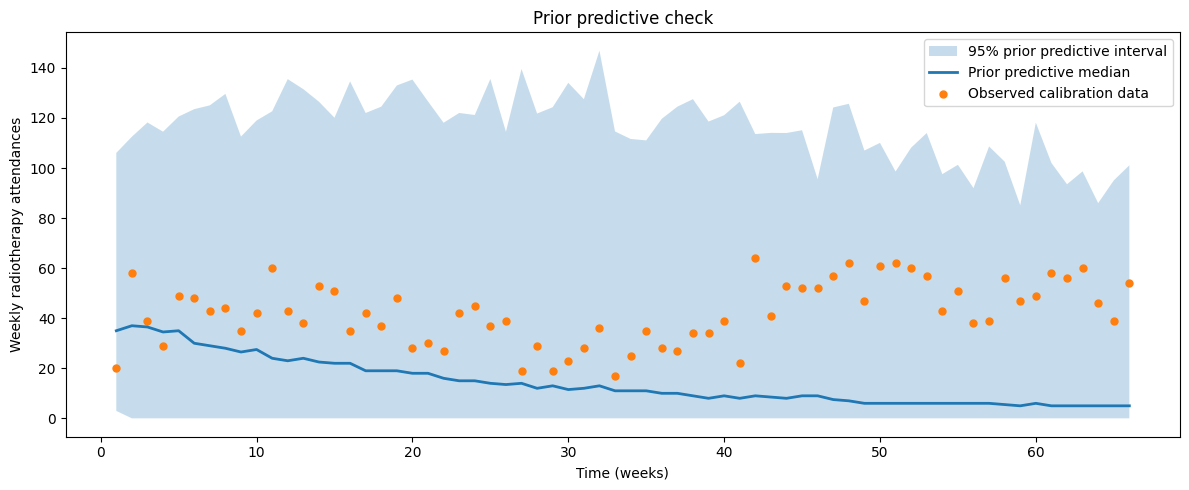

In [ ]:
# ============================================================================
# 21. PRIOR PREDICTIVE CHECK
# ============================================================================

plt.figure(figsize=(12, 5))

plt.fill_between(
    t_calib,
    prior_pred_lower,
    prior_pred_upper,
    alpha=0.25,
    label="95% prior predictive interval"
)

plt.plot(
    t_calib,
    prior_pred_median,
    linewidth=2,
    label="Prior predictive median"
)

plt.scatter(
    t_calib,
    Y_calib,
    s=25,
    label="Observed calibration data"
)

plt.xlabel("Time (weeks)")
plt.ylabel("Weekly radiotherapy attendances")

plt.title(
    "Prior predictive check"
)

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================================
# 22. PRIOR PREDICTIVE NUMERICAL SUMMARY
# ============================================================================

prior_summary = pd.DataFrame({
    "Statistic": [
        "Observed calibration minimum",
        "Observed calibration maximum",
        "Observed calibration mean",
        "Prior predictive 2.5% overall",
        "Prior predictive median overall",
        "Prior predictive 97.5% overall",
        "Maximum prior predictive count"
    ],

    "Value": [
        np.min(Y_calib),
        np.max(Y_calib),
        np.mean(Y_calib),

        np.quantile(
            prior_predictive_counts,
            0.025
        ),

        np.median(
            prior_predictive_counts
        ),

        np.quantile(
            prior_predictive_counts,
            0.975
        ),

        np.max(
            prior_predictive_counts
        )
    ]
})

display(prior_summary)

,Statistic,Value
0,Observed calibration minimum,17.000000
1,Observed calibration maximum,64.000000
2,Observed calibration mean,42.136364
3,Prior predictive 2.5% overall,0.000000
4,Prior predictive median overall,13.000000
5,Prior predictive 97.5% overall,119.000000
6,Maximum prior predictive count,921.000000


In [ ]:
# ============================================================================
# 23. CMDSTANPY ENVIRONMENT
# ============================================================================

import cmdstanpy
from cmdstanpy import CmdStanModel

print("CmdStanPy version:", cmdstanpy.__version__)

try:
    print("CmdStan path:", cmdstanpy.cmdstan_path())
except ValueError:
    print(
        "CmdStan is not installed yet.\n"
        "Run the installation cell below once, then restart this cell."
    )

CmdStanPy version: 1.3.0
CmdStan is not installed yet.
Run the installation cell below once, then restart this cell.


In [ ]:
# OPTIONAL - ONLY IF CMDSTAN IS NOT INSTALLED

#from cmdstanpy import install_cmdstan

#install_cmdstan()

In [ ]:
# ============================================================================
# 24. DATA FOR STAN
# ============================================================================

# Calibration observation times:
# t = 1, ..., 66
#
# t = 0 was used only to initialize the model.

t_stan = np.asarray(t_calib, dtype=float)

# Fixed parameters required inside the ODE
#
# Order:
# 1  mu_B
# 2  mu_T
# 3  mu_R
# 4  mu_P
# 5  beta1
# 6  beta2
# 7  gamma
# 8  p_T
# 9  p_R
# 10 p_P

fixed_stan = np.array([
    MU_B,
    MU_T,
    MU_R,
    MU_P,
    BETA1,
    BETA2,
    GAMMA,
    P_T,
    P_R,
    P_P
], dtype=float)


# Prior hyperparameters in the order
# Lambda, alpha, q, mu_M, phi

prior_names = [
    "Lambda",
    "alpha",
    "q",
    "mu_M",
    "phi"
]

prior_m = np.array(
    [prior_parameters[name]["m"] for name in prior_names],
    dtype=float
)

prior_s = np.array(
    [prior_parameters[name]["s"] for name in prior_names],
    dtype=float
)


stan_data = {
    "N": int(len(Y_calib)),
    "y": Y_calib.astype(int).tolist(),
    "ts": t_stan.tolist(),

    "x0": X0.tolist(),
    "fixed": fixed_stan.tolist(),

    "kappa": float(KAPPA),
    "pi_rt": float(PI_RT),

    "prior_m": prior_m.tolist(),
    "prior_s": prior_s.tolist()
}


print("Number of observations entering likelihood:", stan_data["N"])
print("First likelihood time:", stan_data["ts"][0])
print("Last likelihood time :", stan_data["ts"][-1])

assert stan_data["N"] == 66
assert len(stan_data["y"]) == len(stan_data["ts"])

Number of observations entering likelihood: 66
First likelihood time: 1.0
Last likelihood time : 66.0


In [ ]:
# ============================================================================
# 25. STAN MODEL
# ============================================================================

stan_code = r"""
functions {

    vector care_pathway_ode(
        real t,
        vector X,
        vector theta,
        vector fixed
    ) {

        // ------------------------------------------------------------
        // State variables
        // ------------------------------------------------------------

        real B = X[1];
        real T = X[2];
        real R = X[3];
        real P = X[4];
        real M = X[5];

        // ------------------------------------------------------------
        // Estimated mechanistic parameters
        // ------------------------------------------------------------

        real Lambda = theta[1];
        real alpha  = theta[2];
        real q      = theta[3];
        real mu_M   = theta[4];

        // ------------------------------------------------------------
        // Fixed parameters
        // ------------------------------------------------------------

        real mu_B  = fixed[1];
        real mu_T  = fixed[2];
        real mu_R  = fixed[3];
        real mu_P  = fixed[4];

        real beta1 = fixed[5];
        real beta2 = fixed[6];
        real gamma = fixed[7];

        real p_T   = fixed[8];
        real p_R   = fixed[9];
        real p_P   = fixed[10];

        // ------------------------------------------------------------
        // Auxiliary quantity
        // ------------------------------------------------------------

        real Ncare = T + R + P;

        vector[5] dX;

        // ------------------------------------------------------------
        // ODE system
        // ------------------------------------------------------------

        dX[1] =
            Lambda
            - alpha * M * B
            - mu_B * B;

        dX[2] =
            alpha * M * B
            + beta2 * M * R
            - beta1 * M * T
            - mu_T * T;

        dX[3] =
            beta1 * M * T
            - (beta2 + gamma) * M * R
            - mu_R * R;

        dX[4] =
            gamma * M * R
            - mu_P * P;

        dX[5] =
            q * Ncare
            - mu_M * M
            - p_T * (alpha * M * B + beta2 * M * R)
            - p_R * beta1 * M * T
            - p_P * gamma * M * R;

        return dX;
    }
}


data {

    int<lower=1> N;

    array[N] int<lower=0> y;
    array[N] real ts;

    vector[5] x0;
    vector[10] fixed;

    real<lower=0> kappa;
    real<lower=0, upper=1> pi_rt;

    vector[5] prior_m;
    vector<lower=0>[5] prior_s;
}


parameters {

    // log-parameters:
    //
    // [1] log Lambda
    // [2] log alpha
    // [3] log q
    // [4] log mu_M
    // [5] log phi

    vector[5] log_par;
}


transformed parameters {

    // ------------------------------------------------------------
    // Back-transform parameters
    // ------------------------------------------------------------

    real<lower=0> Lambda = exp(log_par[1]);
    real<lower=0> alpha  = exp(log_par[2]);
    real<lower=0> q      = exp(log_par[3]);
    real<lower=0> mu_M   = exp(log_par[4]);

    real<lower=0> phi    = exp(log_par[5]);

    vector[4] theta;

    theta[1] = Lambda;
    theta[2] = alpha;
    theta[3] = q;
    theta[4] = mu_M;

    // ------------------------------------------------------------
    // Solve mechanistic model
    // ------------------------------------------------------------

    array[N] vector[5] X_hat =
        ode_bdf(
            care_pathway_ode,
            x0,
            0.0,
            ts,
            theta,
            fixed
        );

    // ------------------------------------------------------------
    // Observation means
    // ------------------------------------------------------------

    vector[N] mu_obs;

    for (i in 1:N) {

        // Small numerical protection against an exactly zero mean
        mu_obs[i] =
            fmax(
                1e-9,
                kappa * pi_rt * X_hat[i][2]
            );
    }
}


model {

    // ============================================================
    // PRIORS
    // ============================================================

    log_par ~ normal(
        prior_m,
        prior_s
    );

    // ============================================================
    // LIKELIHOOD
    // ============================================================

    for (i in 1:N) {

        y[i] ~ neg_binomial_2(
            mu_obs[i],
            phi
        );
    }
}


generated quantities {

    // ------------------------------------------------------------
    // Pointwise log-likelihood
    // ------------------------------------------------------------

    vector[N] log_lik;

    // ------------------------------------------------------------
    // Posterior predictive observations
    // ------------------------------------------------------------

    array[N] int y_rep;

    for (i in 1:N) {

        log_lik[i] =
            neg_binomial_2_lpmf(
                y[i] | mu_obs[i], phi
            );

        y_rep[i] =
            neg_binomial_2_rng(
                mu_obs[i], phi
            );
    }
}
"""

In [ ]:
# ============================================================================
# 26. WRITE AND COMPILE STAN MODEL
# ============================================================================

from pathlib import Path

stan_file = Path("cervical_cancer_bayesian.stan")

stan_file.write_text(
    stan_code,
    encoding="utf-8"
)

print("Stan model written to:")
print(stan_file.resolve())

Stan model written to:
/content/cervical_cancer_bayesian.stan


In [ ]:
# OPTIONAL - ONLY IF CMDSTAN IS NOT INSTALLED

from cmdstanpy import install_cmdstan

install_cmdstan()

CmdStan install directory: /root/.cmdstan
Installing CmdStan version: 2.40.0
Download successful, file: /tmp/tmpqant9dj0
Extracting distribution
Unpacked download as cmdstan-2.40.0
Building version cmdstan-2.40.0, may take several minutes, depending on your system.
Installed cmdstan-2.40.0
Test model compilation


True

In [ ]:
# ============================================================================
# 23. CMDSTANPY ENVIRONMENT
# ============================================================================

import cmdstanpy
from cmdstanpy import CmdStanModel

print("CmdStanPy version:", cmdstanpy.__version__)

try:
    print("CmdStan path:", cmdstanpy.cmdstan_path())
except ValueError:
    print(
        "CmdStan is not installed yet.\n"
        "Run the installation cell below once, then restart this cell."
    )

CmdStanPy version: 1.3.0
CmdStan is not installed yet.
Run the installation cell below once, then restart this cell.


In [ ]:
model = CmdStanModel(
    stan_file=str(stan_file)
)

print("Stan model compiled successfully.")

ValueError: No CmdStan installation found, run command "install_cmdstan"or (re)activate your conda environment!

In [ ]:
# ============================================================================
# 27. MCMC INITIAL VALUES
# ============================================================================

N_CHAINS = 4

rng_init = np.random.default_rng(SEED + 100)

chain_inits = []

for chain in range(N_CHAINS):

    # Start around the prior centre,
    # with moderate chain-specific perturbations.

    log_par_init = (
        prior_m
        + rng_init.normal(
            loc=0.0,
            scale=0.25,
            size=5
        )
    )

    chain_inits.append({
        "log_par": log_par_init.tolist()
    })


pd.DataFrame(
    np.vstack([
        np.exp(init["log_par"])
        for init in chain_inits
    ]),
    columns=[
        "Lambda",
        "alpha",
        "q",
        "mu_M",
        "phi"
    ],
    index=[
        f"Chain {i+1}"
        for i in range(N_CHAINS)
    ]
)

In [ ]:
# ============================================================================
# 28. PILOT MCMC WITH NUTS
# ============================================================================

fit_pilot = model.sample(
    data=stan_data,

    chains=4,
    parallel_chains=4,

    iter_warmup=500,
    iter_sampling=500,

    seed=SEED,

    inits=chain_inits,

    adapt_delta=0.95,
    max_treedepth=12,

    show_progress=True
)

In [ ]:
# ============================================================================
# 29. AUTOMATIC MCMC DIAGNOSTICS
# ============================================================================

print(
    fit_pilot.diagnose()
)

In [ ]:
# ============================================================================
# 29B. MCMC TRACE PLOTS
# ============================================================================

# Parameters for which convergence must be visually assessed
trace_parameters = [
    "Lambda",
    "alpha",
    "q",
    "mu_M",
    "phi"
]

# CmdStanPy draws:
# shape = (number of post-warmup iterations, number of chains, number of columns)
draws_array = fit_pilot.draws(
    concat_chains=False
)

column_names = list(
    fit_pilot.column_names
)

print("Draws array shape:", draws_array.shape)
print("Number of chains  :", draws_array.shape[1])

# --------------------------------------------------------------------------
# Multi-panel trace plot
# --------------------------------------------------------------------------

n_parameters = len(trace_parameters)

fig, axes = plt.subplots(
    nrows=n_parameters,
    ncols=1,
    figsize=(12, 2.8 * n_parameters),
    sharex=True
)

for ax, parameter in zip(
    axes,
    trace_parameters
):

    # Locate parameter in CmdStan output
    parameter_index = column_names.index(
        parameter
    )

    # Extract all post-warmup draws:
    # rows    = iterations
    # columns = chains
    parameter_draws = draws_array[
        :,
        :,
        parameter_index
    ]

    # Plot each chain
    for chain in range(
        parameter_draws.shape[1]
    ):

        ax.plot(
            np.arange(
                1,
                parameter_draws.shape[0] + 1
            ),
            parameter_draws[:, chain],
            linewidth=0.65,
            alpha=0.80,
            label=f"Chain {chain + 1}"
        )

    ax.set_ylabel(
        parameter
    )

    ax.grid(
        alpha=0.20
    )

# Common x-axis
axes[-1].set_xlabel(
    "Post-warmup iteration"
)

# One common legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    frameon=False
)

fig.suptitle(
    "MCMC trace plots for estimated parameters",
    fontsize=14,
    y=0.995
)

fig.tight_layout(
    rect=[0, 0, 1, 0.97]
)

plt.show()

In [ ]:
# ============================================================================
# 29C. MCMC TRACE PLOTS ON LOG SCALE
# ============================================================================

fig, axes = plt.subplots(
    nrows=len(trace_parameters),
    ncols=1,
    figsize=(12, 2.8 * len(trace_parameters)),
    sharex=True
)

for ax, parameter in zip(
    axes,
    trace_parameters
):

    parameter_index = column_names.index(
        parameter
    )

    parameter_draws = draws_array[
        :,
        :,
        parameter_index
    ]

    log_draws = np.log(
        parameter_draws
    )

    for chain in range(
        log_draws.shape[1]
    ):

        ax.plot(
            np.arange(
                1,
                log_draws.shape[0] + 1
            ),
            log_draws[:, chain],
            linewidth=0.65,
            alpha=0.80,
            label=f"Chain {chain + 1}"
        )

    ax.set_ylabel(
        f"log({parameter})"
    )

    ax.grid(
        alpha=0.20
    )

axes[-1].set_xlabel(
    "Post-warmup iteration"
)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    frameon=False
)

fig.suptitle(
    "MCMC trace plots on the log-parameter scale",
    fontsize=14,
    y=0.995
)

fig.tight_layout(
    rect=[0, 0, 1, 0.97]
)

plt.show()

In [ ]:
# ============================================================================
# 30. POSTERIOR SUMMARY - PILOT RUN
# ============================================================================

parameters_of_interest = [
    "Lambda",
    "alpha",
    "q",
    "mu_M",
    "phi"
]

pilot_summary = fit_pilot.summary()

pilot_parameter_summary = pilot_summary.loc[
    parameters_of_interest
]

display(
    pilot_parameter_summary
)

In [ ]:
# ============================================================================
# 31. AUTOMATIC CONVERGENCE CHECK
# ============================================================================

diagnostic_table = pilot_parameter_summary[
    [
        "ESS_bulk",
        "ESS_tail",
        "R_hat"
    ]
].copy()

display(diagnostic_table)


max_rhat = diagnostic_table["R_hat"].max()
min_bulk_ess = diagnostic_table["ESS_bulk"].min()
min_tail_ess = diagnostic_table["ESS_tail"].min()


print(f"Maximum R-hat : {max_rhat:.4f}")
print(f"Minimum bulk ESS : {min_bulk_ess:.1f}")
print(f"Minimum tail ESS : {min_tail_ess:.1f}")


if max_rhat < 1.01:
    print("R-hat criterion satisfied.")
else:
    print("WARNING: R-hat criterion NOT satisfied.")

In [ ]:
# ============================================================================
# 32. EXTRACT POSTERIOR DRAWS
# ============================================================================

posterior_draws = fit_pilot.draws_pd(
    vars=[
        "Lambda",
        "alpha",
        "q",
        "mu_M",
        "phi"
    ]
)

print(
    "Number of posterior draws:",
    len(posterior_draws)
)

display(
    posterior_draws.head()
)

In [ ]:
# ============================================================================
# 33. PRIOR VS POSTERIOR DISTRIBUTIONS
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import lognorm
from scipy.stats import gaussian_kde


# --------------------------------------------------------------------------
# Parameters to compare
# --------------------------------------------------------------------------

parameters_prior_posterior = [
    "Lambda",
    "alpha",
    "q",
    "mu_M",
    "phi"
]


# Labels for publication-quality figures
parameter_labels = {
    "Lambda": r"$\Lambda$",
    "alpha": r"$\alpha$",
    "q": r"$q$",
    "mu_M": r"$\mu_M$",
    "phi": r"$\phi$"
}


# --------------------------------------------------------------------------
# Figure layout
# --------------------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(12, 12)
)

axes = axes.flatten()


# --------------------------------------------------------------------------
# Prior/posterior comparison
# --------------------------------------------------------------------------

for ax, parameter in zip(
    axes,
    parameters_prior_posterior
):

    # ==============================================================
    # 1. PRIOR DISTRIBUTION
    # ==============================================================

    m_prior = prior_parameters[
        parameter
    ]["m"]

    s_prior = prior_parameters[
        parameter
    ]["s"]

    prior_dist = lognorm(
        s=s_prior,
        scale=np.exp(m_prior)
    )


    # ==============================================================
    # 2. POSTERIOR DRAWS
    # ==============================================================

    posterior_values = posterior_draws[
        parameter
    ].to_numpy()

    # Safety check
    posterior_values = posterior_values[
        posterior_values > 0
    ]


    # ==============================================================
    # 3. COMMON PLOTTING RANGE
    # ==============================================================

    # Prior range
    prior_low = prior_dist.ppf(
        0.001
    )

    prior_high = prior_dist.ppf(
        0.999
    )

    # Posterior range
    posterior_low = np.quantile(
        posterior_values,
        0.001
    )

    posterior_high = np.quantile(
        posterior_values,
        0.999
    )

    x_min = min(
        prior_low,
        posterior_low
    )

    x_max = max(
        prior_high,
        posterior_high
    )

    # Positive logarithmic grid
    x_grid = np.logspace(
        np.log10(x_min),
        np.log10(x_max),
        600
    )


    # ==============================================================
    # 4. PRIOR DENSITY
    # ==============================================================

    prior_density = prior_dist.pdf(
        x_grid
    )


    # ==============================================================
    # 5. POSTERIOR DENSITY
    #
    # KDE is performed on log(parameter), then transformed back
    # to the natural scale:
    #
    # f_X(x) = f_logX(log(x)) / x
    # ==============================================================

    log_posterior = np.log(
        posterior_values
    )

    posterior_kde_log = gaussian_kde(
        log_posterior
    )

    posterior_density = (
        posterior_kde_log(
            np.log(x_grid)
        )
        / x_grid
    )


    # ==============================================================
    # 6. POSTERIOR SUMMARY
    # ==============================================================

    posterior_median = np.median(
        posterior_values
    )

    posterior_lower = np.quantile(
        posterior_values,
        0.025
    )

    posterior_upper = np.quantile(
        posterior_values,
        0.975
    )


    # ==============================================================
    # 7. PLOT
    # ==============================================================

    ax.plot(
        x_grid,
        prior_density,
        linestyle="--",
        linewidth=2.0,
        label="Prior"
    )

    ax.plot(
        x_grid,
        posterior_density,
        linestyle="-",
        linewidth=2.2,
        label="Posterior"
    )

    ax.axvline(
        posterior_median,
        linestyle=":",
        linewidth=1.8,
        label="Posterior median"
    )

    # Optional: posterior 95% credible interval
    ax.axvspan(
        posterior_lower,
        posterior_upper,
        alpha=0.10,
        label="95% credible interval"
    )


    # ==============================================================
    # 8. AXIS FORMATTING
    # ==============================================================

    ax.set_xscale(
        "log"
    )

    ax.set_xlabel(
        parameter_labels[parameter]
    )

    ax.set_ylabel(
        "Density"
    )

    ax.set_title(
        f"Prior vs posterior for {parameter_labels[parameter]}"
    )

    ax.grid(
        alpha=0.20
    )


# --------------------------------------------------------------------------
# Remove unused sixth panel
# --------------------------------------------------------------------------

fig.delaxes(
    axes[-1]
)


# --------------------------------------------------------------------------
# Common legend
# --------------------------------------------------------------------------

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 0.995)
)


fig.suptitle(
    "Prior and posterior distributions of estimated parameters",
    fontsize=15,
    y=1.02
)

fig.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()

In [ ]:
# ============================================================================
# 33B. PRIOR-TO-POSTERIOR UNCERTAINTY REDUCTION
# ============================================================================

prior_posterior_comparison = []


for parameter in parameters_prior_posterior:

    # --------------------------------------------------------------
    # Prior
    # --------------------------------------------------------------

    m_prior = prior_parameters[
        parameter
    ]["m"]

    s_prior = prior_parameters[
        parameter
    ]["s"]

    prior_dist = lognorm(
        s=s_prior,
        scale=np.exp(m_prior)
    )

    prior_q025 = prior_dist.ppf(
        0.025
    )

    prior_q50 = prior_dist.ppf(
        0.50
    )

    prior_q975 = prior_dist.ppf(
        0.975
    )


    # --------------------------------------------------------------
    # Posterior
    # --------------------------------------------------------------

    posterior_values = posterior_draws[
        parameter
    ].to_numpy()

    posterior_q025 = np.quantile(
        posterior_values,
        0.025
    )

    posterior_q50 = np.quantile(
        posterior_values,
        0.50
    )

    posterior_q975 = np.quantile(
        posterior_values,
        0.975
    )


    # --------------------------------------------------------------
    # Interval widths
    # --------------------------------------------------------------

    prior_width = (
        prior_q975
        - prior_q025
    )

    posterior_width = (
        posterior_q975
        - posterior_q025
    )

    width_ratio = (
        posterior_width
        / prior_width
    )


    prior_posterior_comparison.append({
        "Parameter": parameter,

        "Prior median": prior_q50,

        "Posterior median": posterior_q50,

        "Prior 2.5%": prior_q025,

        "Prior 97.5%": prior_q975,

        "Posterior 2.5%": posterior_q025,

        "Posterior 97.5%": posterior_q975,

        "Posterior/Prior width": width_ratio
    })


prior_posterior_table = pd.DataFrame(
    prior_posterior_comparison
)

print(
    prior_posterior_table.to_string(
        index=False
    )
)

In [ ]:
fit_pilot.diagnose()

In [ ]:
pilot_parameter_summary

In [ ]:
# ============================================================================
# 34. POSTERIOR CREDIBLE INTERVALS
# ============================================================================

posterior_summary_table = []

for parameter in parameters_of_interest:

    x = posterior_draws[parameter].to_numpy()

    posterior_summary_table.append({
        "Parameter": parameter,
        "Mean": np.mean(x),
        "Median": np.median(x),
        "SD": np.std(x, ddof=1),
        "2.5%": np.quantile(x, 0.025),
        "5%": np.quantile(x, 0.05),
        "95%": np.quantile(x, 0.95),
        "97.5%": np.quantile(x, 0.975)
    })


posterior_summary_table = pd.DataFrame(
    posterior_summary_table
)

display(posterior_summary_table)

In [ ]:
# ============================================================================
# 35. POSTERIOR CORRELATION MATRIX
# ============================================================================

mechanistic_parameters = [
    "Lambda",
    "alpha",
    "q",
    "mu_M"
]

posterior_corr = posterior_draws[
    mechanistic_parameters
].corr()

display(posterior_corr)

In [ ]:
# ============================================================================
# POSTERIOR CORRELATION HEATMAP
# ============================================================================

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(
    posterior_corr.values,
    vmin=-1,
    vmax=1
)

ax.set_xticks(
    np.arange(len(mechanistic_parameters))
)

ax.set_yticks(
    np.arange(len(mechanistic_parameters))
)

ax.set_xticklabels(
    mechanistic_parameters
)

ax.set_yticklabels(
    mechanistic_parameters
)

for i in range(len(mechanistic_parameters)):
    for j in range(len(mechanistic_parameters)):

        ax.text(
            j,
            i,
            f"{posterior_corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

fig.colorbar(
    im,
    ax=ax,
    label="Posterior correlation"
)

ax.set_title(
    "Posterior correlation between estimated parameters"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# 36. POSTERIOR CORRELATION ON LOG SCALE
# ============================================================================

log_posterior = np.log(
    posterior_draws[
        mechanistic_parameters
    ]
)

log_corr = log_posterior.corr()

display(log_corr)

In [ ]:
# ============================================================================
# 37. FULL POSTERIOR PROPAGATION: CALIBRATION + HELD-OUT PERIOD
# ============================================================================

# Full observation time grid:
# t = 0, ..., 83

t_full = np.asarray(
    t_obs,
    dtype=float
)

N_full = len(t_full)

N_posterior = len(
    posterior_draws
)

print(
    "Number of posterior draws:",
    N_posterior
)

print(
    "Prediction horizon:",
    f"{t_full[0]:.0f} to {t_full[-1]:.0f} weeks"
)


# Reproducible posterior predictive simulation
rng_postpred = np.random.default_rng(
    SEED + 500
)


# Storage
mu_full_list = []
yrep_full_list = []

valid_draw_indices = []
failed_draw_indices = []


for s in range(N_posterior):

    # ------------------------------------------------------------
    # Mechanistic parameters
    # ------------------------------------------------------------

    theta_s = np.array([
        posterior_draws.iloc[s]["Lambda"],
        posterior_draws.iloc[s]["alpha"],
        posterior_draws.iloc[s]["q"],
        posterior_draws.iloc[s]["mu_M"]
    ], dtype=float)

    phi_s = float(
        posterior_draws.iloc[s]["phi"]
    )


    # ------------------------------------------------------------
    # Solve from t = 0 to t = 83
    # ------------------------------------------------------------

    try:

        solution_s = simulate_model(
            theta=theta_s,
            t_eval=t_full,
            X_init=X0
        )

        mu_s = extract_expected_attendance(
            solution_s
        )

        # Numerical protection
        mu_s = np.maximum(
            mu_s,
            1e-10
        )


        # --------------------------------------------------------
        # Negative-binomial posterior predictive realization
        #
        # Var(Y) = mu + mu^2 / phi
        #
        # NumPy parameterization:
        # n = phi
        # p = phi / (phi + mu)
        # --------------------------------------------------------

        p_s = (
            phi_s
            /
            (phi_s + mu_s)
        )

        yrep_s = rng_postpred.negative_binomial(
            n=phi_s,
            p=p_s
        )


        mu_full_list.append(
            mu_s
        )

        yrep_full_list.append(
            yrep_s
        )

        valid_draw_indices.append(
            s
        )


    except Exception:

        failed_draw_indices.append(
            s
        )


# Convert to arrays
mu_full_draws = np.asarray(
    mu_full_list
)

yrep_full_draws = np.asarray(
    yrep_full_list
)


print()
print(
    "Valid posterior trajectories:",
    len(valid_draw_indices)
)

print(
    "Failed posterior trajectories:",
    len(failed_draw_indices)
)

print(
    "Failure rate:",
    f"{100 * len(failed_draw_indices) / N_posterior:.2f}%"
)

print()
print(
    "mu_full_draws shape:",
    mu_full_draws.shape
)

print(
    "yrep_full_draws shape:",
    yrep_full_draws.shape
)

In [ ]:
# ============================================================================
# 38. POSTERIOR AND POSTERIOR PREDICTIVE QUANTILES
# ============================================================================

# --------------------------------------------------------------------------
# Posterior uncertainty in the expected model trajectory
# --------------------------------------------------------------------------

mu_full_median = np.median(
    mu_full_draws,
    axis=0
)

mu_full_lower95 = np.quantile(
    mu_full_draws,
    0.025,
    axis=0
)

mu_full_upper95 = np.quantile(
    mu_full_draws,
    0.975,
    axis=0
)


# --------------------------------------------------------------------------
# 75% posterior predictive interval
# --------------------------------------------------------------------------

yrep_lower75 = np.quantile(
    yrep_full_draws,
    0.125,
    axis=0
)

yrep_upper75 = np.quantile(
    yrep_full_draws,
    0.875,
    axis=0
)


# --------------------------------------------------------------------------
# 95% posterior predictive interval
# --------------------------------------------------------------------------

yrep_lower95 = np.quantile(
    yrep_full_draws,
    0.025,
    axis=0
)

yrep_upper95 = np.quantile(
    yrep_full_draws,
    0.975,
    axis=0
)


print(
    "Posterior predictive intervals computed successfully."
)

In [ ]:
# ============================================================================
# 39. FINAL POSTERIOR PREDICTIVE FIGURE:
#     CALIBRATION + HELD-OUT DATA
# ============================================================================

fig, ax = plt.subplots(
    figsize=(13, 6)
)


# --------------------------------------------------------------------------
# 95% posterior predictive interval
# --------------------------------------------------------------------------

ax.fill_between(
    t_full,
    yrep_lower95,
    yrep_upper95,
    alpha=0.18,
    label="95% posterior predictive interval"
)


# --------------------------------------------------------------------------
# 75% posterior predictive interval
# --------------------------------------------------------------------------

ax.fill_between(
    t_full,
    yrep_lower75,
    yrep_upper75,
    alpha=0.32,
    label="75% posterior predictive interval"
)


# --------------------------------------------------------------------------
# Posterior median expected trajectory
# --------------------------------------------------------------------------

ax.plot(
    t_full,
    mu_full_median,
    linewidth=2.2,
    label="Posterior median prediction"
)


# --------------------------------------------------------------------------
# Initialization observation
# --------------------------------------------------------------------------

ax.scatter(
    t_obs[0],
    Y_obs[0],
    marker="D",
    s=55,
    zorder=5,
    label="Initialization observation"
)


# --------------------------------------------------------------------------
# Calibration observations
# --------------------------------------------------------------------------

ax.scatter(
    t_calib,
    Y_calib,
    marker="o",
    s=32,
    zorder=5,
    label="Calibration data"
)


# --------------------------------------------------------------------------
# Held-out observations
# --------------------------------------------------------------------------

ax.scatter(
    t_test,
    Y_test,
    marker="s",
    s=38,
    zorder=5,
    label="Held-out data"
)


# --------------------------------------------------------------------------
# Train-test boundary
# --------------------------------------------------------------------------

boundary = (
    t_test[0]
    - 0.5
)

ax.axvline(
    boundary,
    linestyle="--",
    linewidth=1.5,
    label="Calibration / held-out boundary"
)


# --------------------------------------------------------------------------
# Labels
# --------------------------------------------------------------------------

ax.set_xlabel(
    "Time (weeks)"
)

ax.set_ylabel(
    "Weekly radiotherapy attendances"
)

ax.set_title(
    "Bayesian posterior predictive fit and held-out validation"
)

ax.grid(
    alpha=0.20
)

ax.legend(
    frameon=False,
    ncol=2
)

fig.tight_layout()

plt.show()

In [ ]:
# ============================================================================
# 40. EXTRACT CALIBRATION AND HELD-OUT PREDICTIONS
# ============================================================================

# Week 0 is used only for initialization.

# Calibration:
# t = 1, ..., 66

mu_calib_median = mu_full_median[
    1:len(t_train)
]


# Held-out:
# t = 67, ..., 83

mu_test_median = mu_full_median[
    len(t_train):
]


print(
    "Calibration observations:",
    len(Y_calib)
)

print(
    "Calibration predictions:",
    len(mu_calib_median)
)

print()

print(
    "Held-out observations:",
    len(Y_test)
)

print(
    "Held-out predictions:",
    len(mu_test_median)
)


assert len(
    mu_calib_median
) == len(
    Y_calib
)

assert len(
    mu_test_median
) == len(
    Y_test
)

In [ ]:
# ============================================================================
# 41. CALIBRATION AND HELD-OUT PERFORMANCE METRICS
# ============================================================================

def prediction_metrics(
    y_true,
    y_pred,
    baseline_value=None
):

    y_true = np.asarray(
        y_true,
        dtype=float
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float
    )


    # ----------------------------------------------------------------------
    # Raw metrics
    # ----------------------------------------------------------------------

    RMSE = np.sqrt(
        np.mean(
            (y_true - y_pred)**2
        )
    )

    MAE = np.mean(
        np.abs(
            y_true - y_pred
        )
    )


    ss_res = np.sum(
        (y_true - y_pred)**2
    )

    ss_tot = np.sum(
        (
            y_true
            - np.mean(y_true)
        )**2
    )

    R2 = (
        1.0
        - ss_res / ss_tot
        if ss_tot > 0
        else np.nan
    )


    # ----------------------------------------------------------------------
    # Mean-normalized errors
    # ----------------------------------------------------------------------

    mean_observed = np.mean(
        y_true
    )

    CV_RMSE = (
        RMSE
        / mean_observed
    )

    NMAE = (
        MAE
        / mean_observed
    )


    # ----------------------------------------------------------------------
    # Baseline prediction
    # ----------------------------------------------------------------------

    if baseline_value is None:

        baseline_value = mean_observed


    baseline_prediction = np.full(
        len(y_true),
        baseline_value,
        dtype=float
    )


    RMSE_baseline = np.sqrt(
        np.mean(
            (
                y_true
                - baseline_prediction
            )**2
        )
    )


    relative_RMSE = (
        RMSE
        / RMSE_baseline
    )


    return {
        "RMSE": RMSE,
        "MAE": MAE,
        "R2": R2,

        "CV_RMSE": CV_RMSE,
        "CV_RMSE_percent": 100 * CV_RMSE,

        "NMAE": NMAE,
        "NMAE_percent": 100 * NMAE,

        "RMSE_baseline": RMSE_baseline,
        "relative_RMSE": relative_RMSE
    }

    # Mean available at the end of training
train_mean_baseline = np.mean(
    Y_calib
)


calibration_metrics = prediction_metrics(
    Y_calib,
    mu_calib_median,
    baseline_value=train_mean_baseline
)


test_metrics = prediction_metrics(
    Y_test,
    mu_test_median,

    # VERY IMPORTANT:
    # test baseline uses TRAINING information only
    baseline_value=train_mean_baseline
)

metrics_comparison = pd.DataFrame({

    "Metric": [
        "RMSE",
        "MAE",
        "R²",
        "CV(RMSE)",
        "CV(RMSE) (%)",
        "NMAE",
        "NMAE (%)",
        "Baseline RMSE",
        "Relative RMSE"
    ],

    "Calibration": [
        calibration_metrics["RMSE"],
        calibration_metrics["MAE"],
        calibration_metrics["R2"],

        calibration_metrics["CV_RMSE"],
        calibration_metrics["CV_RMSE_percent"],

        calibration_metrics["NMAE"],
        calibration_metrics["NMAE_percent"],

        calibration_metrics["RMSE_baseline"],
        calibration_metrics["relative_RMSE"]
    ],

    "Held-out": [
        test_metrics["RMSE"],
        test_metrics["MAE"],
        test_metrics["R2"],

        test_metrics["CV_RMSE"],
        test_metrics["CV_RMSE_percent"],

        test_metrics["NMAE"],
        test_metrics["NMAE_percent"],

        test_metrics["RMSE_baseline"],
        test_metrics["relative_RMSE"]
    ]
})


print(
    metrics_comparison.round(4).to_string(
        index=False
    )
)

In [ ]:
# ============================================================================
# 42. POSTERIOR PREDICTIVE COVERAGE
# ============================================================================

# Calibration indices:
# weeks 1,...,66

calib_slice = slice(
    1,
    len(t_train)
)


# Test indices:
# weeks 67,...,83

test_slice = slice(
    len(t_train),
    len(t_obs)
)


# --------------------------------------------------------------------------
# 75% coverage
# --------------------------------------------------------------------------

coverage75_calib = np.mean(
    (
        Y_calib
        >= yrep_lower75[calib_slice]
    )
    &
    (
        Y_calib
        <= yrep_upper75[calib_slice]
    )
)


coverage75_test = np.mean(
    (
        Y_test
        >= yrep_lower75[test_slice]
    )
    &
    (
        Y_test
        <= yrep_upper75[test_slice]
    )
)


# --------------------------------------------------------------------------
# 95% coverage
# --------------------------------------------------------------------------

coverage95_calib = np.mean(
    (
        Y_calib
        >= yrep_lower95[calib_slice]
    )
    &
    (
        Y_calib
        <= yrep_upper95[calib_slice]
    )
)


coverage95_test = np.mean(
    (
        Y_test
        >= yrep_lower95[test_slice]
    )
    &
    (
        Y_test
        <= yrep_upper95[test_slice]
    )
)


coverage_table = pd.DataFrame({

    "Predictive interval": [
        "75%",
        "95%"
    ],

    "Calibration coverage (%)": [
        100 * coverage75_calib,
        100 * coverage95_calib
    ],

    "Held-out coverage (%)": [
        100 * coverage75_test,
        100 * coverage95_test
    ]
})


print(
    coverage_table.round(2).to_string(
        index=False
    )
)